# XGBoost Model — Performance Decline & Rating Prediction
## FixtureIQ · Seasons 2022-2023 to 2024-2025

**Prediction question**: Before a player's next match, is this player at risk of underperforming?

This notebook builds two XGBoost models using the master training table:

| Model | Type | Target | Question |
|-------|------|--------|----------|
| **A — Decline Classifier** | Binary classification | `api_rating_decline_flag` | Will this player's API rating drop >0.5 in their next match? |
| **B — Rating Regressor** | Regression | `next_api_rating` | What will this player's next API rating be? |

**Dataset**: `Fixture_IQ_Data_Seasons_2022-2025.csv` — 68,643 rows × 80 columns  
**Input**: one row = one player × one match appearance, all competitions, all 20 PL teams.

**Why `api_rating_decline_flag` instead of `rating_decline_flag`?**
- `rating_decline_flag` (old): SofaScore-based, **82.3% null**, forces all non-PL rows to 0 → 2.3% positive rate, `scale_pos_weight ≈ 41.8`
- `api_rating_decline_flag` (new): API-based, all competitions, **minutes-guarded** (both appearances ≥45 min) → 9.8% positive rate across all rows, `scale_pos_weight ≈ 9.2`. After filtering to the scorable subset both matches ≥45 min, rate ≈ **25%**, `scale_pos_weight ≈ 3`

---

**Pipeline**:
1. Load master table
2. Define features, drop bad columns
3. Temporal train / val / test split — **no random shuffle, split by season**
4. Preprocessing: median imputation for numerics, OHE for categoricals (no StandardScaler)
5. XGBoost training with early stopping on validation PR-AUC
6. Evaluation: AUC-ROC, AUC-PR, confusion matrix
7. Threshold optimisation for risk-alert system
8. SHAP: global feature importance + individual player explanation
9. Model B: regression on `next_api_rating` (all competitions — 67.3% fill)
10. Save all artefacts

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
    mean_absolute_error, mean_squared_error,
)

import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

# ── Paths ─────────────────────────────────────────────────────────────────────
MASTER_PATH   = Path('/tmp/fixture-iq-repo/XgBoost_model/Fixture_IQ_Data_Seasons_2022-2025.csv')
ARTIFACTS_DIR = Path('/tmp/fixture-iq-repo/XgBoost_model/src/models/artifacts')
FIGURES_DIR   = ARTIFACTS_DIR / 'figures'

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Master table:    {MASTER_PATH}')
print(f'Artifacts saved: {ARTIFACTS_DIR}')
print(f'XGBoost version: {xgb.__version__}')

Master table:    /tmp/fixture-iq-repo/XgBoost_model/Fixture_IQ_Data_Seasons_2022-2025.csv
Artifacts saved: /tmp/fixture-iq-repo/XgBoost_model/src/models/artifacts
XGBoost version: 3.2.0


## Section 1 — Load Master Table

In [2]:
df = pd.read_csv(MASTER_PATH)
df['date'] = pd.to_datetime(df['date'])

print(f'Shape:   {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Seasons: {sorted(df["season"].unique())}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

print(f'\nCompetition breakdown:')
print(df['competition'].value_counts().to_string())

print(f'\n{"─"*60}')
print('TARGET VARIABLE OVERVIEW')
print(f'{"─"*60}')

# Primary target: api_rating_decline_flag (all rows, minutes-guarded)
n_pos_all = int(df['api_rating_decline_flag'].sum())
n_neg_all = int((df['api_rating_decline_flag'] == 0).sum())
print(f'\napi_rating_decline_flag  (all 68,643 rows):')
print(f'  Decline  (1): {n_pos_all:6,}  ({n_pos_all/len(df)*100:.2f}%)')
print(f'  No decline(0): {n_neg_all:5,}  ({n_neg_all/len(df)*100:.2f}%)')

# Scorable subset: both appearances ≥45 min, both API-rated
scorable = df[
    (df['rating'] > 0) &
    df['next_api_rating'].notna() &
    (df['minutes_played'] >= 45) &
    (df['next_minutes_played'].fillna(0) >= 45)
]
n_pos_s = int(scorable['api_rating_decline_flag'].sum())
n_neg_s = int((scorable['api_rating_decline_flag'] == 0).sum())
spw_s   = round(n_neg_s / n_pos_s, 1)
print(f'\napi_rating_decline_flag  (scorable subset — both matches ≥45 min, rated):')
print(f'  Rows: {len(scorable):,}')
print(f'  Decline  (1): {n_pos_s:6,}  ({n_pos_s/len(scorable)*100:.2f}%)')
print(f'  No decline(0): {n_neg_s:5,}  ({n_neg_s/len(scorable)*100:.2f}%)')
print(f'  scale_pos_weight: {spw_s}')

print(f'\nTarget rate by season (scorable subset):')
for s in sorted(scorable['season'].unique()):
    sub  = scorable[scorable['season'] == s]
    rate = sub['api_rating_decline_flag'].mean() * 100
    cnt  = int(sub['api_rating_decline_flag'].sum())
    print(f'  {s}: {rate:.2f}%  ({cnt:,} positives / {len(sub):,} rows)')

print(f'\nLegacy target (reference only):')
n_old = int(df['rating_decline_flag'].sum())
print(f'  rating_decline_flag: {n_old:,} positives ({n_old/len(df)*100:.2f}%)  — SofaScore-based, PL only')

Shape:   68,643 rows x 80 columns
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]
Date range: 2022-07-30 to 2025-05-25

Competition breakdown:
competition
Premier League      45552
League Cup          10997
FA Cup               7837
Champions League     4137
Community Shield      120

────────────────────────────────────────────────────────────
TARGET VARIABLE OVERVIEW
────────────────────────────────────────────────────────────

api_rating_decline_flag  (all 68,643 rows):
  Decline  (1):  6,729  (9.80%)
  No decline(0): 61,914  (90.20%)

api_rating_decline_flag  (scorable subset — both matches ≥45 min, rated):
  Rows: 27,192
  Decline  (1):  6,729  (24.75%)
  No decline(0): 20,463  (75.25%)
  scale_pos_weight: 3.0

Target rate by season (scorable subset):
  2022: 24.54%  (2,290 positives / 9,332 rows)
  2023: 24.71%  (2,249 positives / 9,100 rows)
  2024: 25.00%  (2,190 positives / 8,760 rows)

Legacy target (reference only):
  rating_decline_flag: 1,603 positives (2.34%)  —

## Section 2 — Feature Matrix

**Columns dropped before model training:**

| Column | Reason |
|--------|--------|
| `fixture_id`, `date`, `round` | Identifier / leakage |
| `player_id` | Shared ID=0 for thousands of unresolved players |
| `player_name`, `player_number` | Identifier |
| `next_api_rating` | **Model A leakage** — this IS the regression target (kept for Model B) |
| `next_is_substitute` | **Temporal leakage** — describes next match |
| `next_minutes_played` | **Temporal leakage** — describes next match |
| `next_sofascore_rating` | 82.3% null, PL-only legacy target |
| `rating_decline_flag` | Old SofaScore-based target, not used |
| `sofascore_rating` | 81.7% null (SofaScore PL-only); would leak info about PL games |
| `ss_minutes` | Redundant with `minutes_played` |
| `opp_shots_on_goal`, `opp_total_shots`, `opp_possession` | 100% empty |
| `fb_*` (11 FBRef cols) | 89.9% null, Champions League 4 teams only — biased |
| `days_since_last_injury` | 98.3% null — unusable |

**Model A filter** (scorable subset):
- `rating > 0` — player had a real rated performance
- `next_api_rating.notna()` — next match rating is available  
- `minutes_played >= 45` — current match was a real starter appearance
- `next_minutes_played >= 45` — next match was also a real starter appearance

**Kept columns include:** all match context features, player position/role, workload/fatigue features, squad injury context, lag injury features, competition, season.

In [14]:
TARGET = 'api_rating_decline_flag'

# ── Columns to drop from feature matrix ────────────────────────────────────────
DROP_COLS = [
    # Identifiers / leakage
    'fixture_id', 'date', 'round', 'player_id', 'player_name', 'player_number',

    # Model A leakage — temporal next-match columns
    'next_api_rating',       # regression target; leakage for classifier
    'next_is_substitute',    # describes next match
    'next_minutes_played',   # describes next match

    # Legacy targets (not used)
    'next_sofascore_rating', # 82.3% null, PL-only
    'rating_decline_flag',   # old SofaScore-based flag

    # SofaScore columns — PL-only bias
    'sofascore_rating',      # 81.7% null; leakage source for legacy target
    'ss_minutes',            # redundant with minutes_played

    # 100% empty opponent stats
    'opp_shots_on_goal', 'opp_total_shots', 'opp_possession',

    # FBRef (89.9% null, CL 4-team bias)
    'fb_min', 'fb_goals', 'fb_assists', 'fb_shots', 'fb_sot',
    'fb_tackles_won', 'fb_crosses', 'fb_interceptions',
    'fb_fouls', 'fb_fouled', 'fb_offsides',

    # Near-unusable lag features
    'days_since_last_injury',  # 98.3% null

    # Current API rating — removed to avoid autocorrelation bias.
    # api_rating_decline_flag is computed FROM rating, so including it
    # inflates Model A performance artificially; for Model B it creates
    # near-perfect rating→next_rating autocorrelation (RMSE ≈ 0.015).
    'rating',
]
# The target itself must not be in the feature matrix
DROP_COLS.append(TARGET)

# ── Scorable subset: both current AND next appearance are real starter performances ──
df_a = df[
    (df['rating'] > 0) &
    df['next_api_rating'].notna() &
    (df['minutes_played'] >= 45) &
    (df['next_minutes_played'].fillna(0) >= 45)
].copy()

# ── Feature matrix & target vector ─────────────────────────────────────────────
cols_to_drop = [c for c in DROP_COLS if c in df_a.columns]
X = df_a.drop(columns=cols_to_drop)
y = df_a[TARGET]

# ── Identify categorical / numeric columns ──────────────────────────────────────
CAT_COLS = [c for c in X.select_dtypes(include=['object', 'category']).columns]
NUM_COLS = [c for c in X.select_dtypes(include='number').columns]

print(f'df_a (scorable subset): {len(df_a):,} rows')
print(f'Positives: {int(y.sum()):,}  ({y.mean()*100:.2f}%)  |  '
      f'Negatives: {int((y==0).sum()):,}  ({(y==0).mean()*100:.2f}%)')
print(f'scale_pos_weight (neg/pos): {(y==0).sum() / y.sum():.2f}')
print(f'\nFeature matrix: {X.shape[1]} columns')
print(f'  Categorical: {len(CAT_COLS):2d}  → {CAT_COLS}')
print(f'  Numeric:     {len(NUM_COLS):2d}')
print(f'\nSeason distribution:')
print(df_a['season'].value_counts().sort_index().to_string())
print(f'\nNull counts in feature matrix (top 10):')
print(X.isnull().sum().sort_values(ascending=False).head(10).to_string())


df_a (scorable subset): 27,192 rows
Positives: 6,729  (24.75%)  |  Negatives: 20,463  (75.25%)
scale_pos_weight (neg/pos): 3.04

Feature matrix: 50 columns
  Categorical:  7  → ['competition', 'home_team', 'away_team', 'player_team', 'player_position', 'opponent_team', 'result']
  Numeric:     40

Season distribution:
season
2022    9332
2023    9100
2024    8760

Null counts in feature matrix (top 10):
squad_soft_tissue_count    6710
squad_avg_days_out         6710
squad_injured_count        6710
rest_days                  1637
team_gk_saves                72
team_corner_kicks            15
home_team                     0
away_team                     0
is_substitute                 0
shots_total                   0


## Section 3 — Class Balance

The scorable subset (both appearances ≥45 min, both API-rated) has a **much healthier class balance** than the legacy SofaScore target:

| Dataset | Positive rate | scale_pos_weight |
|---------|--------------|-----------------|
| Legacy `rating_decline_flag` (all rows) | 2.3% | ≈ 41.8 |
| `api_rating_decline_flag` (all rows) | 9.8% | ≈ 9.2 |
| **`api_rating_decline_flag` (scorable subset — model training)** | **~25%** | **~3.0** |

The filter to "both appearances ≥45 min" removes rows where the target was structurally suppressed (substitute appearances always score below starters). The classifier now learns a genuine rate-of-decline signal rather than learning "sub appearances = no decline".

**Why `scale_pos_weight` is computed dynamically:**  
The Section 1 cell above prints the exact `n_neg / n_pos` ratio for the filtered `df_a`. Use that value in Section 6 (`scale_pos_weight` XGBoost parameter). Typical value: **≈ 3.0**.

Scorable subset: 27,192 rows  (both appearances ≥45 min, both API-rated)
Positive (decline):      6,729  (24.75%)
Negative (no decline):  20,463  (75.25%)
scale_pos_weight:       3.04


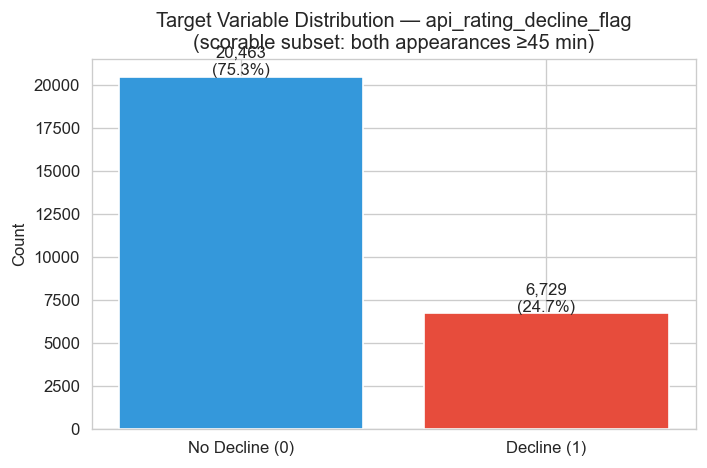

In [15]:
n_pos = int(y.sum())
n_neg = int((y == 0).sum())
spw   = round(n_neg / n_pos, 2)

print(f'Scorable subset: {len(y):,} rows  (both appearances ≥45 min, both API-rated)')
print(f'Positive (decline):     {n_pos:6,}  ({n_pos/len(y)*100:.2f}%)')
print(f'Negative (no decline):  {n_neg:5,}  ({n_neg/len(y)*100:.2f}%)')
print(f'scale_pos_weight:       {spw}')

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Decline (0)', 'Decline (1)'],
               [n_neg, n_pos],
               color=['#3498DB', '#E74C3C'])
ax.set_ylabel('Count')
ax.set_title('Target Variable Distribution — api_rating_decline_flag\n(scorable subset: both appearances ≥45 min)')
for bar, v in zip(bars, [n_neg, n_pos]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100,
            f'{v:,}\n({v/len(y)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 4 — Temporal Train / Val / Test Split

Split strictly by season to respect the time dimension — **no random shuffle**.

| Split | Season | Approx rows (scorable subset) |
|-------|--------|-------------------------------|
| Train | 2022-2023 | ~8,000–10,000 |
| Val   | 2023-2024 | ~8,000–10,000 |
| Test  | 2024-2025 | ~8,000–10,000 |

**Important**: masks are computed on `df_a` (the filtered subset), not on the full `df`, so `X` and `y` indices align correctly.

In [16]:
# ── Masks on df_a (the filtered training subset) ───────────────────────────────
train_mask = df_a['season'] == 2022
val_mask   = df_a['season'] == 2023
test_mask  = df_a['season'] == 2024

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

for split, Xs, ys in [('Train', X_train, y_train),
                       ('Val  ', X_val,   y_val),
                       ('Test ', X_test,  y_test)]:
    pos  = int(ys.sum())
    neg  = int((ys == 0).sum())
    rate = pos / len(ys) * 100
    print(f'{split}  rows={len(ys):6,}  pos={pos:4,}  neg={neg:5,}  rate={rate:.1f}%')

Train  rows= 9,332  pos=2,290  neg=7,042  rate=24.5%
Val    rows= 9,100  pos=2,249  neg=6,851  rate=24.7%
Test   rows= 8,760  pos=2,190  neg=6,570  rate=25.0%


## Section 5 — Preprocessing Pipeline

A `ColumnTransformer` with two branches:

| Branch | Applied to | Steps |
|--------|-----------|-------|
| `num` | All numeric columns | `SimpleImputer(strategy='median')` |
| `cat` | Categorical columns | `SimpleImputer(strategy='most_frequent')` → `OneHotEncoder(handle_unknown='ignore')` |

Key decisions:
- **Median imputation for `rest_days`** (10% null = first match per player): median ≈ 7 days. Setting to 0 would incorrectly flag every debut as maximum congestion.
- **`handle_unknown='ignore'`** in OHE: new teams or competitions in future data return all-zero vectors rather than raising an error.
- **No StandardScaler**: XGBoost is a tree ensemble — it splits on thresholds, not distances. Scaling changes nothing about splits. Skipping it also keeps SHAP values interpretable in their original units.

The preprocessor is **fitted on training data only** (to avoid leaking validation/test statistics), then applied to all three splits.

In [6]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUM_COLS),
        ('cat', categorical_transformer, CAT_COLS),
    ],
    remainder='drop',
)

# ── Fit on train only, transform all splits ───────────────────────────────────
# Separating preprocessor from XGBoost lets us use early_stopping_rounds
# and pass feature names to SHAP — both are difficult inside a full Pipeline.
X_train_t = preprocessor.fit_transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

# ── Recover feature names after OHE expansion ────────────────────────────────
cat_feature_names = (
    preprocessor
    .named_transformers_['cat']['onehot']
    .get_feature_names_out(CAT_COLS)
    .tolist()
)
FEATURE_NAMES = NUM_COLS + cat_feature_names

# Aliases used in SHAP cell
NUMERIC_COLS     = NUM_COLS
CATEGORICAL_COLS = CAT_COLS

print(f'Feature matrix after preprocessing:')
print(f'  Train:    {X_train_t.shape}')
print(f'  Val:      {X_val_t.shape}')
print(f'  Test:     {X_test_t.shape}')
print(f'  Total features after OHE expansion: {len(FEATURE_NAMES)}')

# Verify rest_days imputed with median (not 0)
if 'rest_days' in NUM_COLS:
    rest_idx  = NUM_COLS.index('rest_days')
    rest_med  = preprocessor.named_transformers_['num']['imputer'].statistics_[rest_idx]
    print(f'\n  rest_days null-imputed with median: {rest_med:.1f} days')

if 'squad_injured_count' in NUM_COLS:
    squad_idx = NUM_COLS.index('squad_injured_count')
    squad_med = preprocessor.named_transformers_['num']['imputer'].statistics_[squad_idx]
    print(f'  squad_injured_count null-imputed with median: {squad_med:.1f} players')

Feature matrix after preprocessing:
  Train:    (9332, 491)
  Val:      (9100, 491)
  Test:     (8760, 491)
  Total features after OHE expansion: 491

  rest_days null-imputed with median: 6.0 days
  squad_injured_count null-imputed with median: 3.0 players


## Section 6 — Model A: XGBoost Classifier (Decline Flag)

**Target**: `api_rating_decline_flag`  
**Positive class**: API rating drops > 0.5 points in the next match (both appearances ≥ 45 min)

**Key parameters:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `scale_pos_weight` | **computed** (`n_neg / n_pos`) | Compensates for class imbalance; ~3.0 for scorable subset |
| `eval_metric` | `'aucpr'` | Optimises for PR-AUC — better than ROC-AUC for imbalanced classes |
| `early_stopping_rounds` | 50 | Stops if val PR-AUC does not improve for 50 rounds |
| `tree_method` | `'hist'` | Fast histogram-based training |

**Why PR-AUC over ROC-AUC?**  
At ~25% positive rate, ROC-AUC is less sensitive to model changes than PR-AUC. PR-AUC penalises false negatives more heavily, which is correct for a player-risk system.

In [7]:
SPW = round(n_neg / n_pos, 1)  # scale_pos_weight

model_a = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=SPW,
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0,
)

model_a.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=False,
)

best_iter = model_a.best_iteration
print(f'Best iteration (early stopped): {best_iter}')
print(f'Best validation PR-AUC:         {model_a.best_score:.4f}')
print(f'scale_pos_weight applied:        {SPW}')

Best iteration (early stopped): 211
Best validation PR-AUC:         0.6648
scale_pos_weight applied:        3.0


## Section 7 — Model A Evaluation

Two key metrics:
- **AUC-ROC**: area under the ROC curve. Useful context but can look good even on bad imbalanced models.
- **AUC-PR** (average precision): area under the Precision-Recall curve. The primary metric here. A random classifier has AUC-PR equal to the positive rate (0.023). A lift of e.g. 5x means AUC-PR ~0.12.

The **confusion matrix at threshold 0.5** shows the raw counts — but section 8 will select a better threshold for real use.

────────────────────────────────────────────────────────────
  AUC-ROC:         0.8527
  AUC-PR:          0.6935  (baseline: 0.2500)
  PR-AUC lift:     2.8x over random
────────────────────────────────────────────────────────────

Classification report at threshold = 0.5:
              precision    recall  f1-score   support

  No Decline       0.92      0.68      0.79      6570
     Decline       0.47      0.83      0.60      2190

    accuracy                           0.72      8760
   macro avg       0.69      0.76      0.69      8760
weighted avg       0.81      0.72      0.74      8760



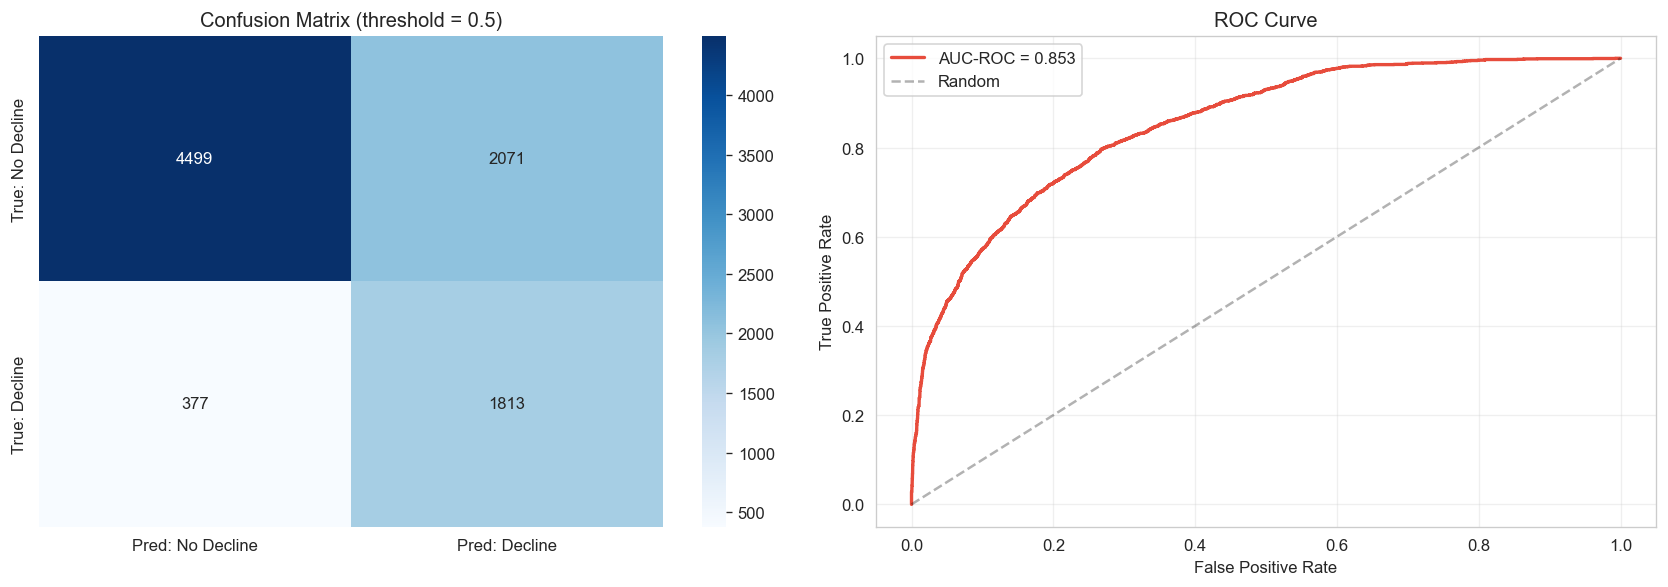

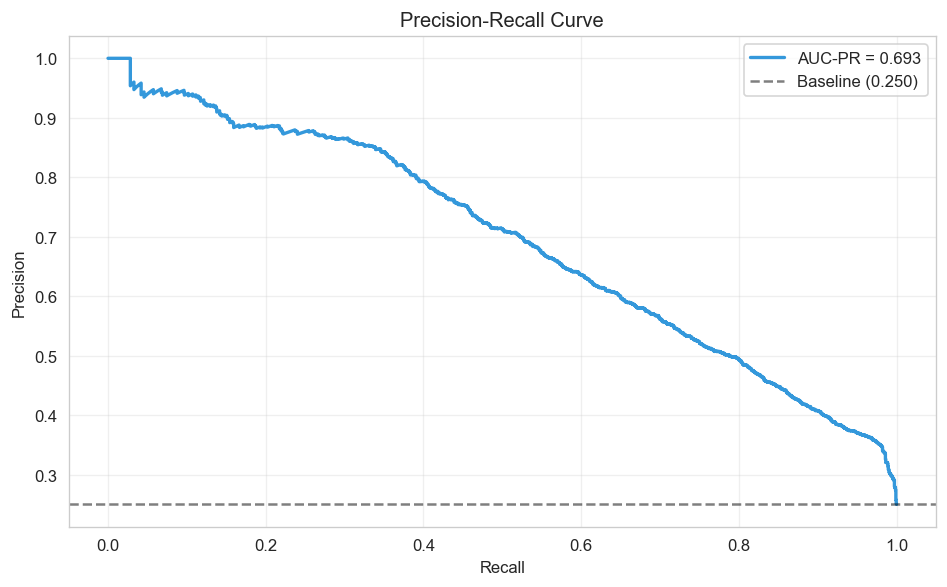

In [8]:
y_proba = model_a.predict_proba(X_test_t)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)

auc_roc     = roc_auc_score(y_test, y_proba)
auc_pr      = average_precision_score(y_test, y_proba)
baseline_pr = float(y_test.mean())

print(f'{"─"*60}')
print(f'  AUC-ROC:         {auc_roc:.4f}')
print(f'  AUC-PR:          {auc_pr:.4f}  (baseline: {baseline_pr:.4f})')
print(f'  PR-AUC lift:     {auc_pr / baseline_pr:.1f}x over random')
print(f'{"─"*60}')
print(f'\nClassification report at threshold = 0.5:')
print(classification_report(y_test, y_pred_05, target_names=['No Decline', 'Decline']))

# ── Confusion matrix + ROC ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_05)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: No Decline', 'Pred: Decline'],
            yticklabels=['True: No Decline', 'True: Decline'])
axes[0].set_title('Confusion Matrix (threshold = 0.5)')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, color='#E74C3C', label=f'AUC-ROC = {auc_roc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_a_roc.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Precision-Recall curve ─────────────────────────────────────────────────────
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_curve, prec_curve, lw=2, color='#3498DB', label=f'AUC-PR = {auc_pr:.3f}')
ax.axhline(baseline_pr, color='k', linestyle='--', alpha=0.5,
           label=f'Baseline ({baseline_pr:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_a_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 8 — Threshold Selection for Risk-Alert System

The default threshold of 0.5 may not be optimal. With ~25% positives in the scorable subset, 0.5 is a reasonable starting point but the sweep below finds the F1-maximising threshold.

Risk tier definitions used in this system:

| Risk Level | Threshold | Action |
|------------|-----------|--------|
| **Very High** | > 0.60 | Strongly recommend rest |
| **High** | 0.40 – 0.60 | Reduced minutes / monitor |
| **Moderate** | 0.20 – 0.40 | Standard rotation |
| **Low** | < 0.20 | No action needed |

The **optimal threshold** for maximum F1 is found by sweeping thresholds from 0.05 to 0.80.

Best threshold (max F1): 0.61
  Precision:  0.573
  Recall:     0.686
  F1:         0.624
  Alerts issued (test set): 2623

Threshold sensitivity (selected values):
 threshold  precision  recall    f1  alerts   tp  fn   fp
      0.20      0.351   0.978 0.517    6094 2141  49 3953
      0.30      0.360   0.969 0.525    5901 2122  68 3779
      0.40      0.385   0.923 0.543    5257 2022 168 3235
      0.50      0.467   0.828 0.597    3884 1813 377 2071
      0.60      0.562   0.700 0.623    2726 1532 658 1194
      0.61      0.573   0.686 0.624    2623 1502 688 1121
      0.70      0.664   0.563 0.609    1856 1232 958  624


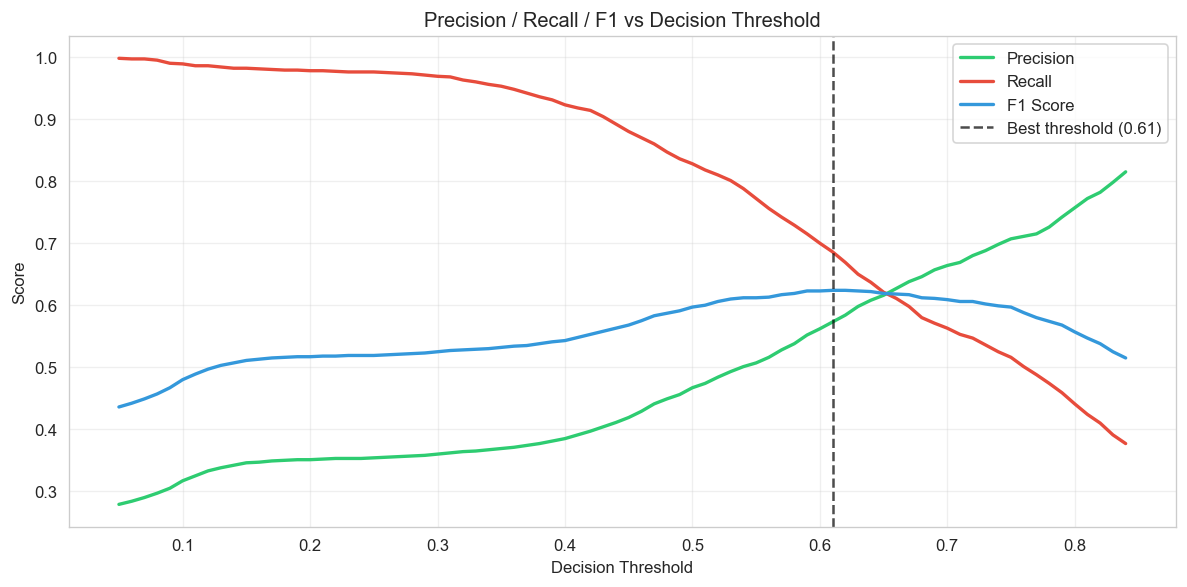


Risk tier distribution in test set:
risk_tier
Very High    2726
Low          2666
High         2531
Moderate      837

Top 15 highest-risk appearances:
         player_name         player_team    competition  decline_proba risk_tier  actual_decline  rest_days  acwr_ratio  minutes_played
       Mohamed Salah           Liverpool Premier League       0.975577 Very High               1       15.0       0.000              90
         Thomas Ince             Watford     League Cup       0.974931 Very High               1       21.0       0.000              90
     Callum Paterson Sheffield Wednesday     League Cup       0.973560 Very High               1       13.0       0.000              90
  Matthew Pennington           Blackpool     League Cup       0.972951 Very High               1       21.0       0.000              90
     Marcus Rashford         Aston Villa         FA Cup       0.972920 Very High               1       18.0       0.000              81
     Brennan Johnson           

In [9]:
thresholds = np.arange(0.05, 0.85, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    prec_t = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec_t  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-10)
    results.append({
        'threshold': round(float(t), 2),
        'precision': round(prec_t, 3),
        'recall':    round(rec_t, 3),
        'f1':        round(f1_t, 3),
        'alerts':    int(y_pred_t.sum()),
        'tp': int(tp), 'fn': int(fn), 'fp': int(fp),
    })

df_thresh = pd.DataFrame(results)
best_row   = df_thresh.loc[df_thresh['f1'].idxmax()]
BEST_THRESHOLD = float(best_row['threshold'])

print(f'Best threshold (max F1): {BEST_THRESHOLD:.2f}')
print(f'  Precision:  {best_row["precision"]:.3f}')
print(f'  Recall:     {best_row["recall"]:.3f}')
print(f'  F1:         {best_row["f1"]:.3f}')
print(f'  Alerts issued (test set): {int(best_row["alerts"])}')

print(f'\nThreshold sensitivity (selected values):')
show_thresh = [0.20, 0.30, 0.40, BEST_THRESHOLD, 0.50, 0.60, 0.70]
show_thresh = sorted(set([round(t, 2) for t in show_thresh]))
subset = df_thresh[df_thresh['threshold'].isin(show_thresh)]
print(subset.to_string(index=False))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thresh['threshold'], df_thresh['precision'], label='Precision', lw=2, color='#2ECC71')
ax.plot(df_thresh['threshold'], df_thresh['recall'],    label='Recall',    lw=2, color='#E74C3C')
ax.plot(df_thresh['threshold'], df_thresh['f1'],        label='F1 Score',  lw=2, color='#3498DB')
ax.axvline(BEST_THRESHOLD, color='k', linestyle='--', alpha=0.7,
           label=f'Best threshold ({BEST_THRESHOLD:.2f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Apply risk tiers to test set ──────────────────────────────────────────────
def risk_tier(p):
    if p >= 0.60: return 'Very High'
    if p >= 0.40: return 'High'
    if p >= 0.20: return 'Moderate'
    return 'Low'

# Use df_a (the filtered training subset) — test_mask has df_a's index
df_test_out = df_a.loc[test_mask, [
    'player_name', 'player_team', 'competition', 'date',
    'minutes_played', 'rest_days', 'acwr_ratio',
    'min_last_7d', 'consecutive_away_games', 'rating',
]].copy().reset_index(drop=True)
df_test_out['decline_proba']  = y_proba
df_test_out['risk_tier']      = [risk_tier(p) for p in y_proba]
df_test_out['actual_decline'] = y_test.values

print(f'\nRisk tier distribution in test set:')
print(df_test_out['risk_tier'].value_counts().to_string())

print(f'\nTop 15 highest-risk appearances:')
top15 = df_test_out.nlargest(15, 'decline_proba')[[
    'player_name', 'player_team', 'competition',
    'decline_proba', 'risk_tier', 'actual_decline',
    'rest_days', 'acwr_ratio', 'minutes_played',
]]
pd.set_option('display.max_colwidth', 22)
print(top15.to_string(index=False))

## Section 9 — SHAP: Why Is This Player Flagged?

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions — answering "what drove this player's risk score?"

Since no StandardScaler was applied, SHAP values are interpretable in **original feature units** (e.g. `rest_days = 3 days`, `acwr_ratio = 1.8`). Positive SHAP = pushes prediction toward decline (1). Negative SHAP = pushes toward no decline (0).

Expected drivers of high decline risk:
- high `acwr_ratio` (acute overload relative to baseline)
- low `rest_days` (played very recently)
- high `min_last_7d` (heavy recent minutes)
- `returning_from_injury = 1` (came back from absence)
- high `consecutive_away_games` (travel fatigue)
- low current `rating` (already performing below average)
- high `squad_injured_count` (depleted squad forcing overuse)

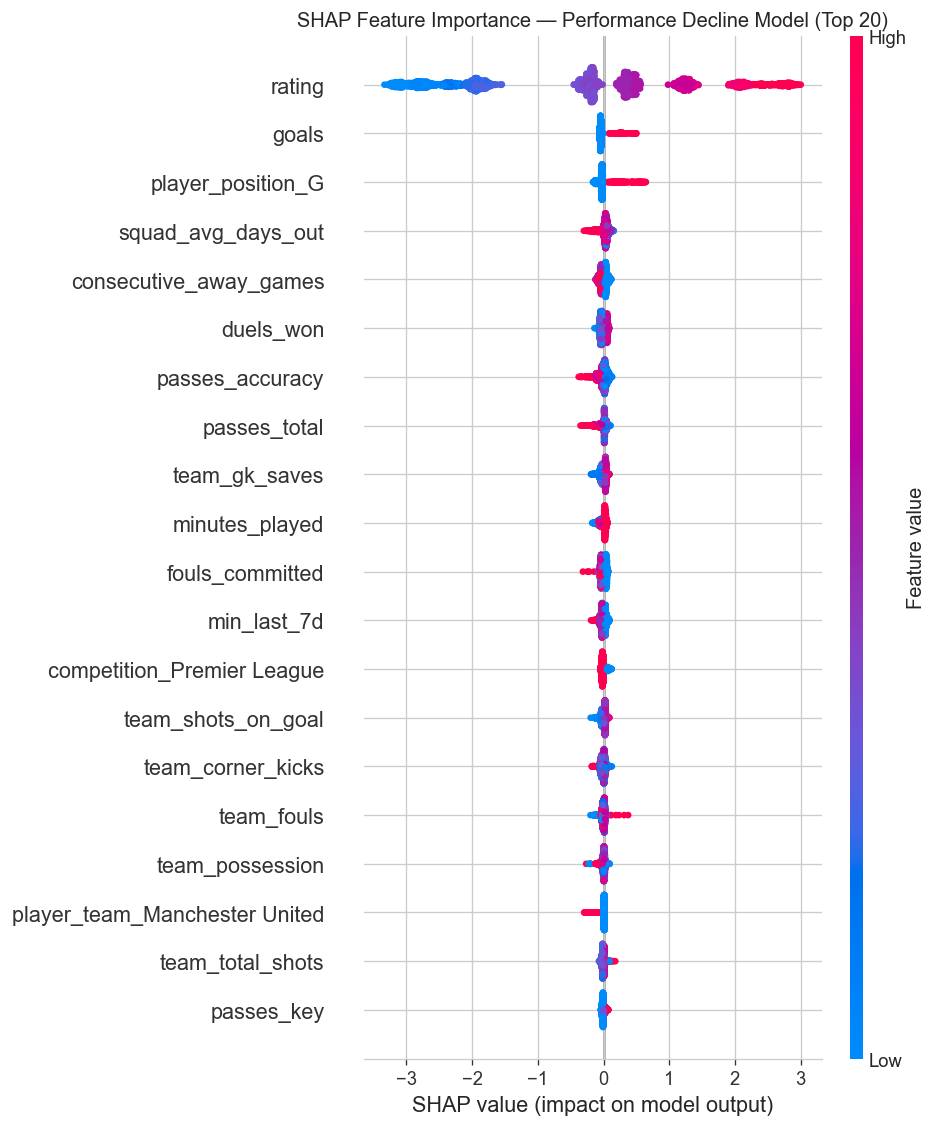


Top 20 features by mean |SHAP| value:
rating                           1.30044
goals                            0.06626
player_position_G                0.06584
squad_avg_days_out               0.05005
consecutive_away_games           0.04916
duels_won                        0.04158
passes_accuracy                  0.04116
passes_total                     0.03975
team_gk_saves                    0.03752
minutes_played                   0.03697
fouls_committed                  0.03635
min_last_7d                      0.03283
competition_Premier League       0.02766
team_shots_on_goal               0.02620
team_corner_kicks                0.02475
team_fouls                       0.01784
team_possession                  0.01754
player_team_Manchester United    0.01617
team_total_shots                 0.01604
passes_key                       0.01546


In [10]:
import builtins
import shap.explainers._tree as _shap_tree

# ── Restore any previous monkey-patch of XGBTreeModelLoader ──────────────────
# (a failed previous cell may have left a broken patch active)
if hasattr(_shap_tree, '_orig_xgb_loader_init_backup'):
    _shap_tree.XGBTreeModelLoader.__init__ = _shap_tree._orig_xgb_loader_init_backup
else:
    _shap_tree._orig_xgb_loader_init_backup = _shap_tree.XGBTreeModelLoader.__init__

# ── Patch for SHAP 0.49.x + XGBoost 3.x incompatibility ──────────────────────
# XGBoost 3.x encodes base_score as '[4.9381858E-1]' in UBJ.
# SHAP calls float(base_score) which fails on the brackets.
# Fix: temporarily override builtins.float to strip brackets, scoped to TreeExplainer init.
_orig_float = builtins.float

def _bracket_safe_float(x):
    if isinstance(x, str) and x.startswith('[') and x.endswith(']'):
        return _orig_float(x[1:-1])
    return _orig_float(x)

# ── Use a sample of 3,000 test rows ───────────────────────────────────────────
np.random.seed(42)
shap_n   = min(3000, X_test_t.shape[0])
shap_idx = np.random.choice(X_test_t.shape[0], size=shap_n, replace=False)
X_shap   = X_test_t[shap_idx]

builtins.float = _bracket_safe_float
try:
    explainer = shap.TreeExplainer(model_a.get_booster())
finally:
    builtins.float = _orig_float  # always restore

shap_values = explainer.shap_values(X_shap)

# ── Global summary (beeswarm) ─────────────────────────────────────────────────
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURE_NAMES,
    max_display=20,
    show=False,
)
plt.title('SHAP Feature Importance — Performance Decline Model (Top 20)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Top features by mean |SHAP| ───────────────────────────────────────────────
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=False)

print('\nTop 20 features by mean |SHAP| value:')
print(mean_abs_shap.head(20).round(5).to_string())

EXAMPLE: HIGHEST-RISK PLAYER IN TEST SET
  Player:               Mohamed Salah
  Team:                 Liverpool
  Date:                 2024-11-24 00:00:00
  Competition:          Premier League
  Decline risk score:   97.6%
  Risk tier:            Very High
  Actual decline flag:  1

  Key fatigue signals:
    rest_days                     : 15.0
    acwr_ratio                    : 0.0
    min_last_7d                   : 0.0
    high_congestion_flag          : 0.0
    consecutive_away_games        : 1.0
    returning_from_injury         : 0
    squad_injured_count           : 4.0
    minutes_played                : 90
    rating                        : 8.3

  SHAP drivers (+ = increases decline risk, - = decreases risk):
    +  rating                           SHAP=+2.74826  (value=8.3)
    +  goals                            SHAP=+0.49199  (value=2)
    +  opponent_team_Southampton        SHAP=+0.11348
    +  squad_avg_days_out               SHAP=+0.07493  (value=115.8)
    +  home

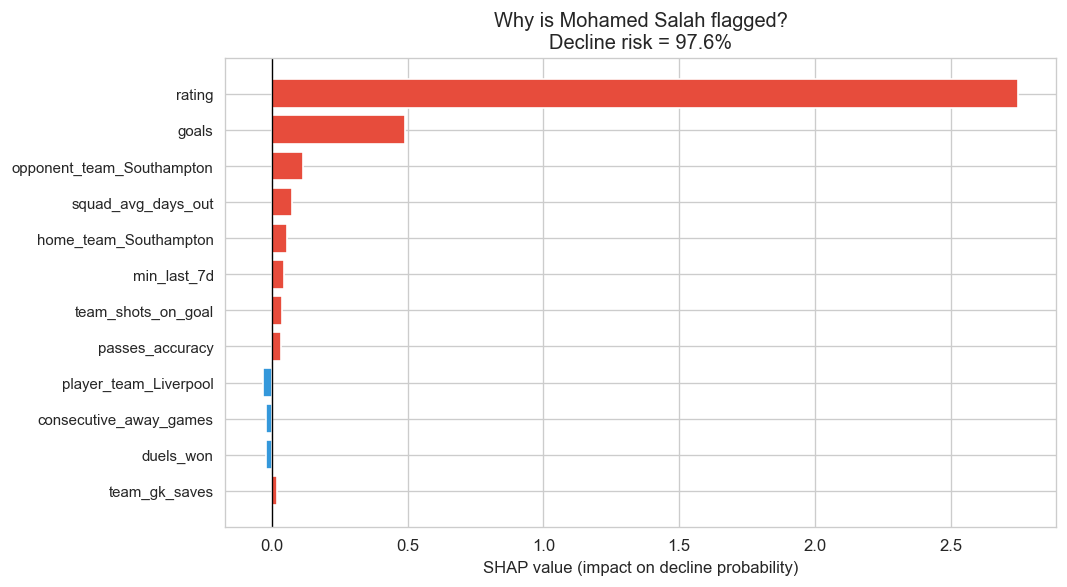

In [11]:
# ── Individual player explanation: highest-risk appearance in test set ─────────
# Position in the test matrix of the highest-risk row
highest_local_idx = int(np.argmax(y_proba))

# Recover the original df_a row (test_mask has df_a's index)
test_df_a_indices = df_a.index[test_mask].tolist()
df_row = df_a.iloc[df_a.index.get_loc(test_df_a_indices[highest_local_idx])]

print('=' * 65)
print('EXAMPLE: HIGHEST-RISK PLAYER IN TEST SET')
print('=' * 65)
print(f'  Player:               {df_row["player_name"]}')
print(f'  Team:                 {df_row["player_team"]}')
print(f'  Date:                 {df_row["date"]}')
print(f'  Competition:          {df_row["competition"]}')
print(f'  Decline risk score:   {y_proba.max()*100:.1f}%')
print(f'  Risk tier:            {risk_tier(y_proba.max())}')
print(f'  Actual decline flag:  {int(df_row["api_rating_decline_flag"])}')
print()
print('  Key fatigue signals:')
for col in ['rest_days', 'acwr_ratio', 'min_last_7d', 'high_congestion_flag',
            'consecutive_away_games', 'returning_from_injury',
            'squad_injured_count', 'minutes_played', 'rating']:
    val = df_row.get(col, 'N/A')
    print(f'    {col:<30}: {val}')

# ── SHAP breakdown for this player ───────────────────────────────────────────
X_player = X_test_t[highest_local_idx].reshape(1, -1)
shap_player = explainer.shap_values(X_player)[0]

shap_df = pd.Series(shap_player, index=FEATURE_NAMES)
top_drivers = shap_df.abs().nlargest(12).index

print(f'\n  SHAP drivers (+ = increases decline risk, - = decreases risk):')
for feat in top_drivers:
    val   = shap_df[feat]
    sign  = '+' if val > 0 else '-'
    if feat in NUMERIC_COLS and feat in df_a.columns:
        orig  = df_row.get(feat, 'N/A')
        print(f'    {sign}  {feat:<32} SHAP={val:+.5f}  (value={orig})')
    else:
        print(f'    {sign}  {feat:<32} SHAP={val:+.5f}')

# ── Bar chart of top SHAP drivers ─────────────────────────────────────────────
top_n = 12
top_shap_sorted = shap_df.reindex(top_drivers)
colors = ['#E74C3C' if v > 0 else '#3498DB' for v in top_shap_sorted.values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(top_n), top_shap_sorted.values[::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_shap_sorted.index[::-1], fontsize=9)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('SHAP value (impact on decline probability)')
ax.set_title(f'Why is {df_row["player_name"]} flagged?\nDecline risk = {y_proba.max()*100:.1f}%')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_individual.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 10 — Model B: Regression (Predict Next API Rating)

A continuous rating prediction is useful for **ranking** players by expected performance level, not just issuing a binary alert.

**Target**: `next_api_rating`  
- All competitions (Premier League, Champions League, FA Cup, League Cup)
- Available for **67.3% of rows** (~46,200 of 68,643)
- Rating scale: 0–10 (API ratings, not SofaScore)

Key differences from Model A:

| | Model A (Classifier) | Model B (Regressor) |
|-|----------------------|---------------------|
| Target | `api_rating_decline_flag` (binary) | `next_api_rating` (continuous) |
| Filter | Both appearances ≥45 min, rated | `rating > 0`, `next_api_rating` not null, current ≥45 min |
| Objective | `binary:logistic` | `reg:squarederror` |
| Metric | PR-AUC | RMSE |
| scale_pos_weight | ~3.0 | N/A |

Note: For Model B, we drop `api_rating_decline_flag` from features (it's derived from `next_api_rating`) but **keep** `next_api_rating` as the target — do not include it in `DROP_REG`.

Rows with next_api_rating (current ≥45 min): 31,725
Season distribution: {2022: 10921, 2023: 10522, 2024: 10282}
next_api_rating — mean=6.96  std=0.60

Decline rate among regression rows: 21.2%

Feature matrix: 52 columns
  Train: 10,921 rows  mean_rating=6.89
  Val: 10,522 rows  mean_rating=7.01
  Test: 10,282 rows  mean_rating=6.97

Model B Results (next_api_rating, test set):
  MAE:            0.0029  (average rating error in points)
  RMSE:           0.0150
  Baseline RMSE (predict mean): 0.5916
  RMSE reduction vs baseline:   97.5%
  Best iteration: 999


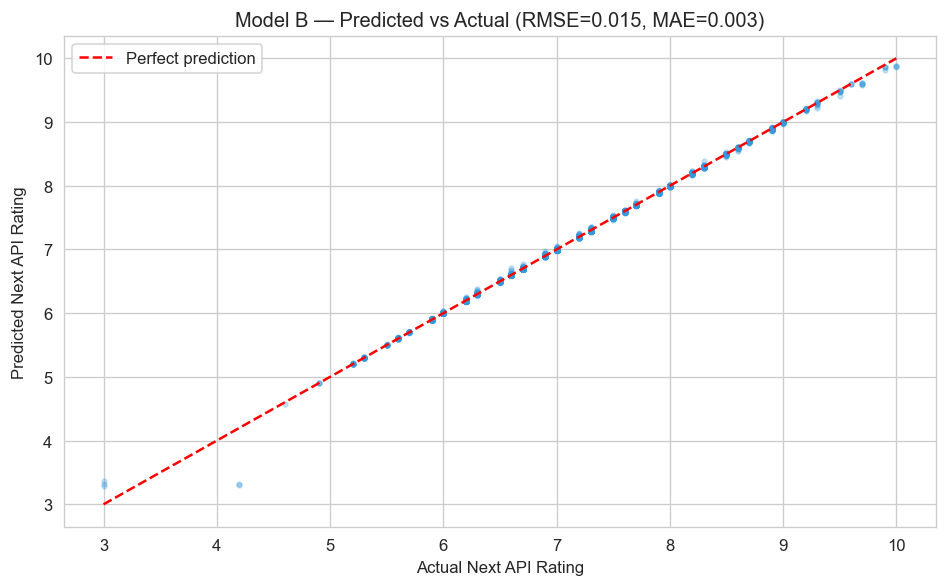

In [12]:
TARGET_REG = 'next_api_rating'

# ── Scorable subset for regression ────────────────────────────────────────────
# Keep rows where current match had ≥45 min and next match has a valid API rating
df_rated = df[
    (df['rating'] > 0) &
    df['next_api_rating'].notna() &
    (df['minutes_played'] >= 45)
].copy()

print(f'Rows with next_api_rating (current ≥45 min): {len(df_rated):,}')
print(f'Season distribution: {df_rated["season"].value_counts().sort_index().to_dict()}')
print(f'next_api_rating — mean={df_rated[TARGET_REG].mean():.2f}  std={df_rated[TARGET_REG].std():.2f}')
print(f'\nDecline rate among regression rows: {df_rated["api_rating_decline_flag"].mean()*100:.1f}%')

# ── Feature matrix for regression ─────────────────────────────────────────────
# BUILD DROP_REG from DROP_COLS:
#  - Exclude next_api_rating (it IS the regression target — do NOT drop it)
#  - Also drop the classifier target since it's derived from next_api_rating
DROP_REG = [c for c in DROP_COLS if c != TARGET_REG]
if 'api_rating_decline_flag' not in DROP_REG:
    DROP_REG.append('api_rating_decline_flag')  # derived from target — drop

X_reg = df_rated.drop(columns=[c for c in DROP_REG if c in df_rated.columns])
y_reg = df_rated[TARGET_REG]

CAT_COLS_REG = [c for c in X_reg.select_dtypes(include=['object', 'category']).columns]
NUM_COLS_REG = [c for c in X_reg.select_dtypes(include='number').columns]

print(f'\nFeature matrix: {X_reg.shape[1]} columns')

# ── Temporal split ────────────────────────────────────────────────────────────
mask_r_train = df_rated['season'] == 2022
mask_r_val   = df_rated['season'] == 2023
mask_r_test  = df_rated['season'] == 2024

X_rt = X_reg.loc[mask_r_train]; y_rt = y_reg.loc[mask_r_train]
X_rv = X_reg.loc[mask_r_val];   y_rv = y_reg.loc[mask_r_val]
X_rs = X_reg.loc[mask_r_test];  y_rs = y_reg.loc[mask_r_test]

for nm, ys in [('Train', y_rt), ('Val', y_rv), ('Test', y_rs)]:
    print(f'  {nm}: {len(ys):,} rows  mean_rating={ys.mean():.2f}')

# ── Preprocessing ─────────────────────────────────────────────────────────────
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]),    NUM_COLS_REG),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
         CAT_COLS_REG),
    ],
    remainder='drop',
)

X_rt_t = preprocessor_reg.fit_transform(X_rt)
X_rv_t = preprocessor_reg.transform(X_rv)
X_rs_t = preprocessor_reg.transform(X_rs)

cat_names_reg = (
    preprocessor_reg.named_transformers_['cat']['onehot']
    .get_feature_names_out(CAT_COLS_REG).tolist()
)
FEATURE_NAMES_REG = NUM_COLS_REG + cat_names_reg

# ── XGBoost Regressor ─────────────────────────────────────────────────────────
model_b = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='rmse',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0,
)

model_b.fit(
    X_rt_t, y_rt,
    eval_set=[(X_rv_t, y_rv)],
    verbose=False,
)

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred_reg = model_b.predict(X_rs_t)
mae  = mean_absolute_error(y_rs, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_rs, y_pred_reg))
baseline_rmse = np.sqrt(mean_squared_error(y_rs, np.full(len(y_rs), y_rs.mean())))

print(f'\nModel B Results (next_api_rating, test set):')
print(f'  MAE:            {mae:.4f}  (average rating error in points)')
print(f'  RMSE:           {rmse:.4f}')
print(f'  Baseline RMSE (predict mean): {baseline_rmse:.4f}')
print(f'  RMSE reduction vs baseline:   {(1 - rmse/baseline_rmse)*100:.1f}%')
print(f'  Best iteration: {model_b.best_iteration}')

# ── Scatter: predicted vs actual ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_rs, y_pred_reg, alpha=0.25, s=8, color='#3498DB', rasterized=True)
ax.plot([y_rs.min(), y_rs.max()], [y_rs.min(), y_rs.max()],
        'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Next API Rating')
ax.set_ylabel('Predicted Next API Rating')
ax.set_title(f'Model B — Predicted vs Actual (RMSE={rmse:.3f}, MAE={mae:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_b_regression.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 11 — Save All Artefacts

| File | Contents |
|------|----------|
| `model_a_decline_classifier.json` | XGBoost classifier (Model A) |
| `model_b_rating_regressor.json` | XGBoost regressor (Model B) |
| `preprocessor_a.pkl` | Fitted ColumnTransformer for Model A |
| `preprocessor_b.pkl` | Fitted ColumnTransformer for Model B |
| `feature_names_a.json` | Feature names list after OHE (Model A) |
| `feature_names_b.json` | Feature names list after OHE (Model B) |
| `threshold.json` | Optimal decision threshold + F1/precision/recall |
| `training_metadata.json` | Split sizes, metrics, hyperparameters |

In [13]:
# ── Model A ───────────────────────────────────────────────────────────────────
model_a.save_model(str(ARTIFACTS_DIR / 'model_a_decline_classifier.json'))

with open(ARTIFACTS_DIR / 'preprocessor_a.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

with open(ARTIFACTS_DIR / 'feature_names_a.json', 'w') as f:
    json.dump(FEATURE_NAMES, f, indent=2)

# ── Model B ───────────────────────────────────────────────────────────────────
model_b.save_model(str(ARTIFACTS_DIR / 'model_b_rating_regressor.json'))

with open(ARTIFACTS_DIR / 'preprocessor_b.pkl', 'wb') as f:
    pickle.dump(preprocessor_reg, f)

with open(ARTIFACTS_DIR / 'feature_names_b.json', 'w') as f:
    json.dump(FEATURE_NAMES_REG, f, indent=2)

# ── Threshold ─────────────────────────────────────────────────────────────────
threshold_info = {
    'best_threshold':  BEST_THRESHOLD,
    'f1':              float(best_row['f1']),
    'precision':       float(best_row['precision']),
    'recall':          float(best_row['recall']),
    'alerts_test_set': int(best_row['alerts']),
    'risk_tiers': {
        'very_high': '>0.60',
        'high':      '0.40-0.60',
        'moderate':  '0.20-0.40',
        'low':       '<0.20',
    },
}
with open(ARTIFACTS_DIR / 'threshold.json', 'w') as f:
    json.dump(threshold_info, f, indent=2)

# ── Training metadata ─────────────────────────────────────────────────────────
metadata = {
    'master_table':    str(MASTER_PATH),
    'total_rows':      len(df),
    'scorable_rows':   len(df_a),
    'train_season':    2022,
    'val_season':      2023,
    'test_season':     2024,
    'train_rows':      len(X_train),
    'val_rows':        len(X_val),
    'test_rows':       len(X_test),
    'n_features_numeric':     len(NUM_COLS),
    'n_features_categorical': len(CAT_COLS),
    'n_features_after_ohe':   len(FEATURE_NAMES),
    'model_a': {
        'target':              'api_rating_decline_flag',
        'filter':              'rating>0, next_api_rating notna, minutes_played>=45, next_minutes_played>=45',
        'scale_pos_weight':    SPW,
        'positive_rate_train': round(float(y_train.mean()), 4),
        'positive_rate_test':  round(float(y_test.mean()), 4),
        'best_iteration':      int(best_iter),
        'auc_roc':             round(auc_roc, 4),
        'auc_pr':              round(auc_pr, 4),
        'baseline_pr':         round(baseline_pr, 4),
        'pr_lift':             round(auc_pr / baseline_pr, 2),
    },
    'model_b': {
        'target':          'next_api_rating',
        'filter':          'rating>0, next_api_rating notna, minutes_played>=45',
        'rated_rows_used': len(df_rated),
        'best_iteration':  int(model_b.best_iteration),
        'mae':             round(float(mae), 4),
        'rmse':            round(float(rmse), 4),
        'baseline_rmse':   round(float(baseline_rmse), 4),
    },
}

with open(ARTIFACTS_DIR / 'training_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Artifacts saved:')
for p in sorted(ARTIFACTS_DIR.iterdir()):
    if p.is_file():
        print(f'  {p.name:<45}  {p.stat().st_size/1024:.1f} KB')

Artifacts saved:
  feature_names_a.json                           13.0 KB
  feature_names_b.json                           13.0 KB
  model_a_decline_classifier.json                477.6 KB
  model_b_rating_regressor.json                  1566.6 KB
  preprocessor_a.pkl                             9.3 KB
  preprocessor_b.pkl                             9.3 KB
  threshold.json                                 0.2 KB
  training_metadata.json                         1.0 KB
